<br/>

<div align="center">
<span style="font-size: 2.5em;">Halo Model Comparison</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Assessing neural network posterior accuracy, precision, and calibration across different dark matter halo models</span>
</div>

## Overview

This notebook extends the extreme-halo comparison to include the Standard Halo Model (SHM). We compare x1, x2, SHM, and their combined posteriors.



In [1]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "dark-matter-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from configs.config import MCConfig, PARAM_RANGES, load_halo_models
from utils.posteriors import posterior_halo_comparison
from performances.metrics import (
    coverage_halo_comparison,
    evaluate_posterior_quality_halo,
    compare_metric_histograms,
)

In [ ]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"   # modelname = "full"            
datatag   = "low"           # datatag = "mid" or "high"      
n_train   = 300_000
halos = ["x1", "x2", "shm"]        # halos = ["x1", "x2", "shm"]
halo_choice = "shm" 

mc_cfg = MCConfig()  
bins = mc_cfg.bins     
top_k     = 10             

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# =============================
# LOAD MODELS
# =============================

models, labels = load_halo_models(
    halos=halos,
    modelname=modelname,
    n_train=n_train,
    datatag=datatag,
    bins=bins,
    top_k=top_k,
    device=device,
)

Loading model from models/wimpy\x1\ntothighest_n300000_low_x1.pt
Loading model from models/wimpy\x2\ntothighest_n300000_low_x2.pt
Loading model from models/wimpy\shm\ntothighest_n300000_low_shm.pt
Loading combined model from models/wimpy\combined\x1_x2_shm\ntothighest_n300000_low_x1_x2_shm.pt


## 1. Qualitative Posterior Comparison

Visualize posteriors from different halo models for a single example spectrum to build intuition for halo-dependent shifts.

In [4]:
# ==========================================================
# Wrapper to run halo comparison
# ==========================================================

def run_halo_comparison(m, cp, halo_choice, models, labels):
    posterior_halo_comparison(
        models=models,
        labels=labels,
        mchi_true=m,
        cp_true=cp,
        halo_choice=halo_choice,
        logm_range=PARAM_RANGES[datatag]["logm_range"],
        logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    )


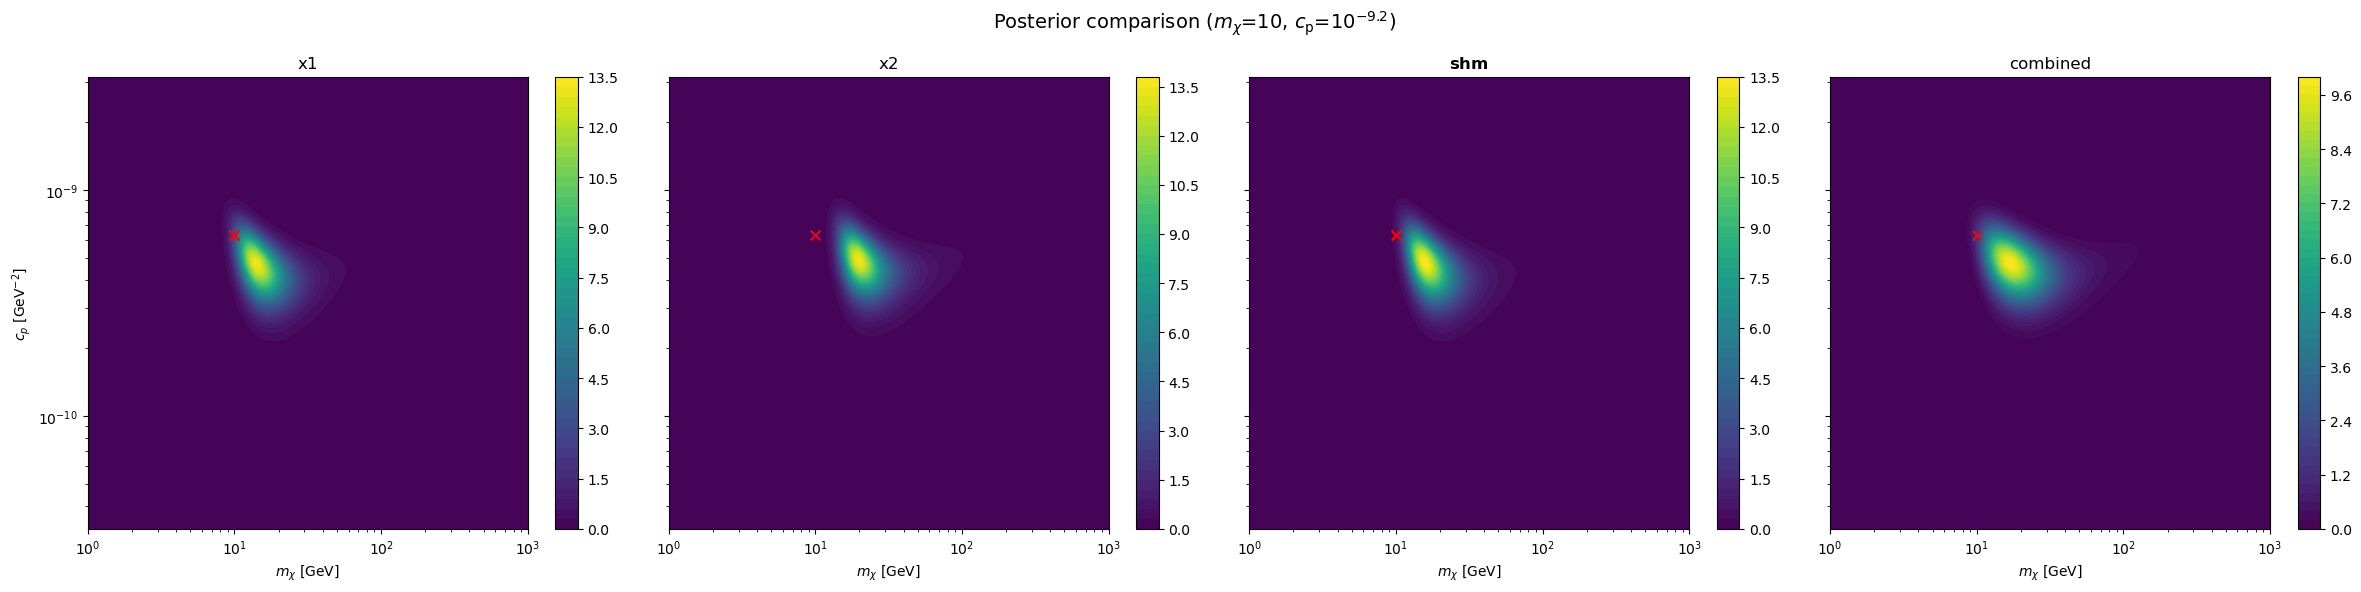

In [5]:
run_halo_comparison(m=10.0, cp=10**(-9.2), halo_choice=halo_choice, models=models, labels=labels)

## 2. Coverage Analysis

### Full Parameter Space
**Expectation**: Coverage should be best for the correct halo model (SHM) and degrade for misspecified models.

**Key Findings**:
- **Correct halo model (SHM)**: Best coverage across nominal levels
- **Extreme models (x1/x2)**: Undercoverage when misspecified
- **Combined model**: Coverage improves relative to misspecified extremes

Loading dataset from:
data/datasets/wimpy/shm/wimpy_n300000_low_shm.pt

Total test samples: 45107
Running coverage test for: x1
Running coverage test for: x2
Running coverage test for: shm
Running coverage test for: combined


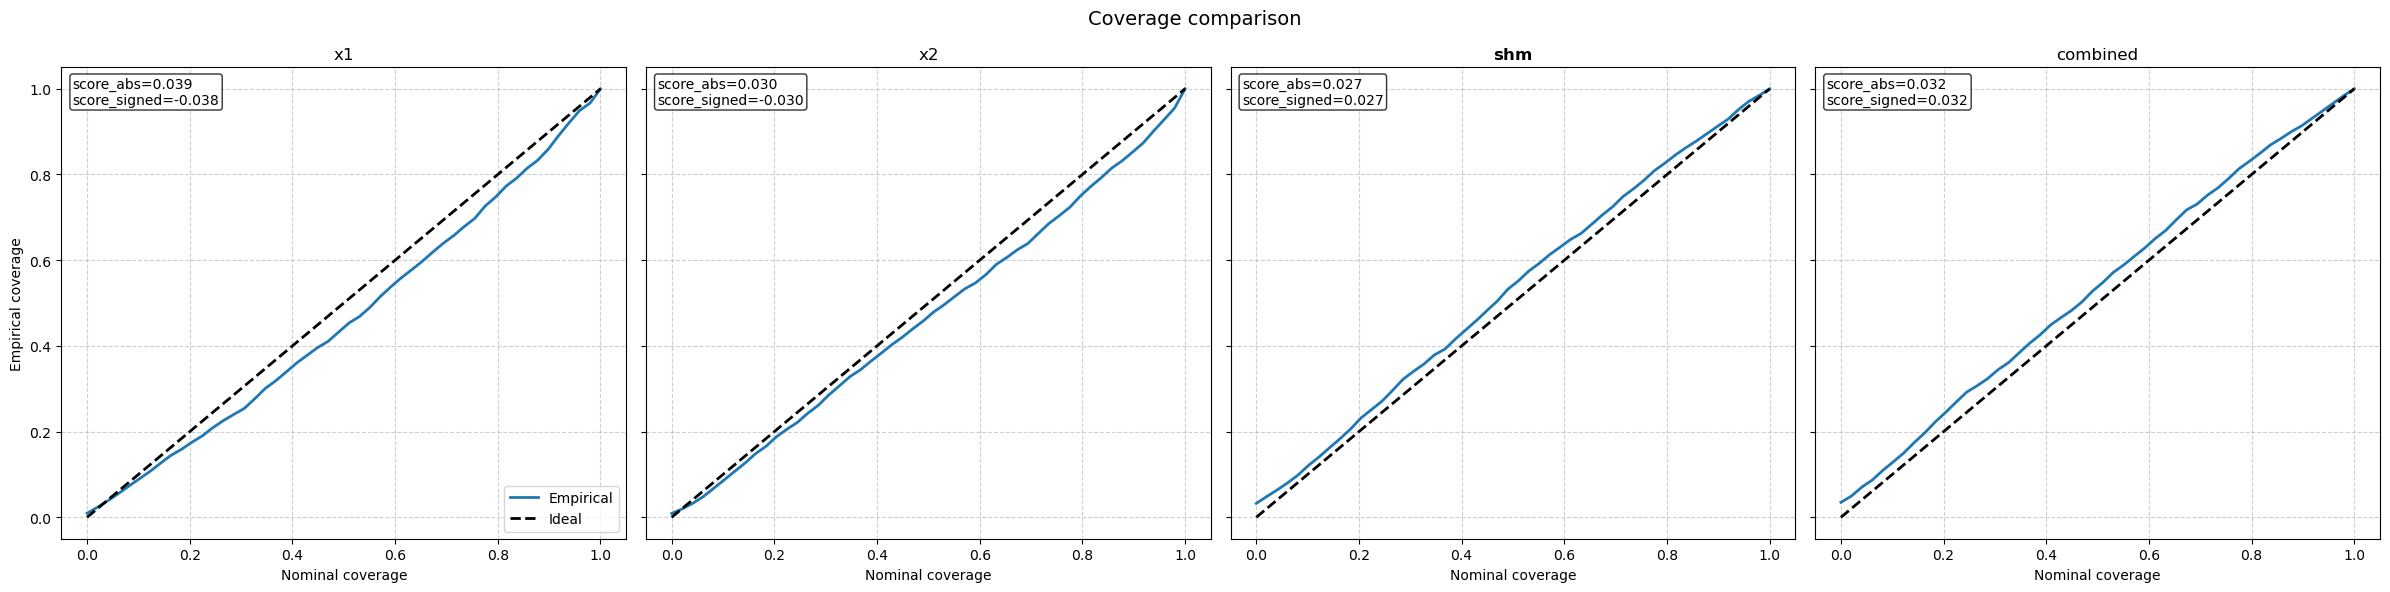

In [6]:
# ==========================================================
# Coverage comparisons 
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=2000,
)

### Focused Parameter Region

We zoom into a low-mass window where halo differences are most pronounced to better expose misspecification effects.

**Note**: Coverage alone does not distinguish overly broad from overly narrow posteriors, so we add accuracy/precision metrics below.

Loading dataset from:
data/datasets/wimpy/shm/wimpy_n300000_low_shm.pt

Filtered test samples: 7629
Running coverage test for: x1
Running coverage test for: x2
Running coverage test for: shm
Running coverage test for: combined


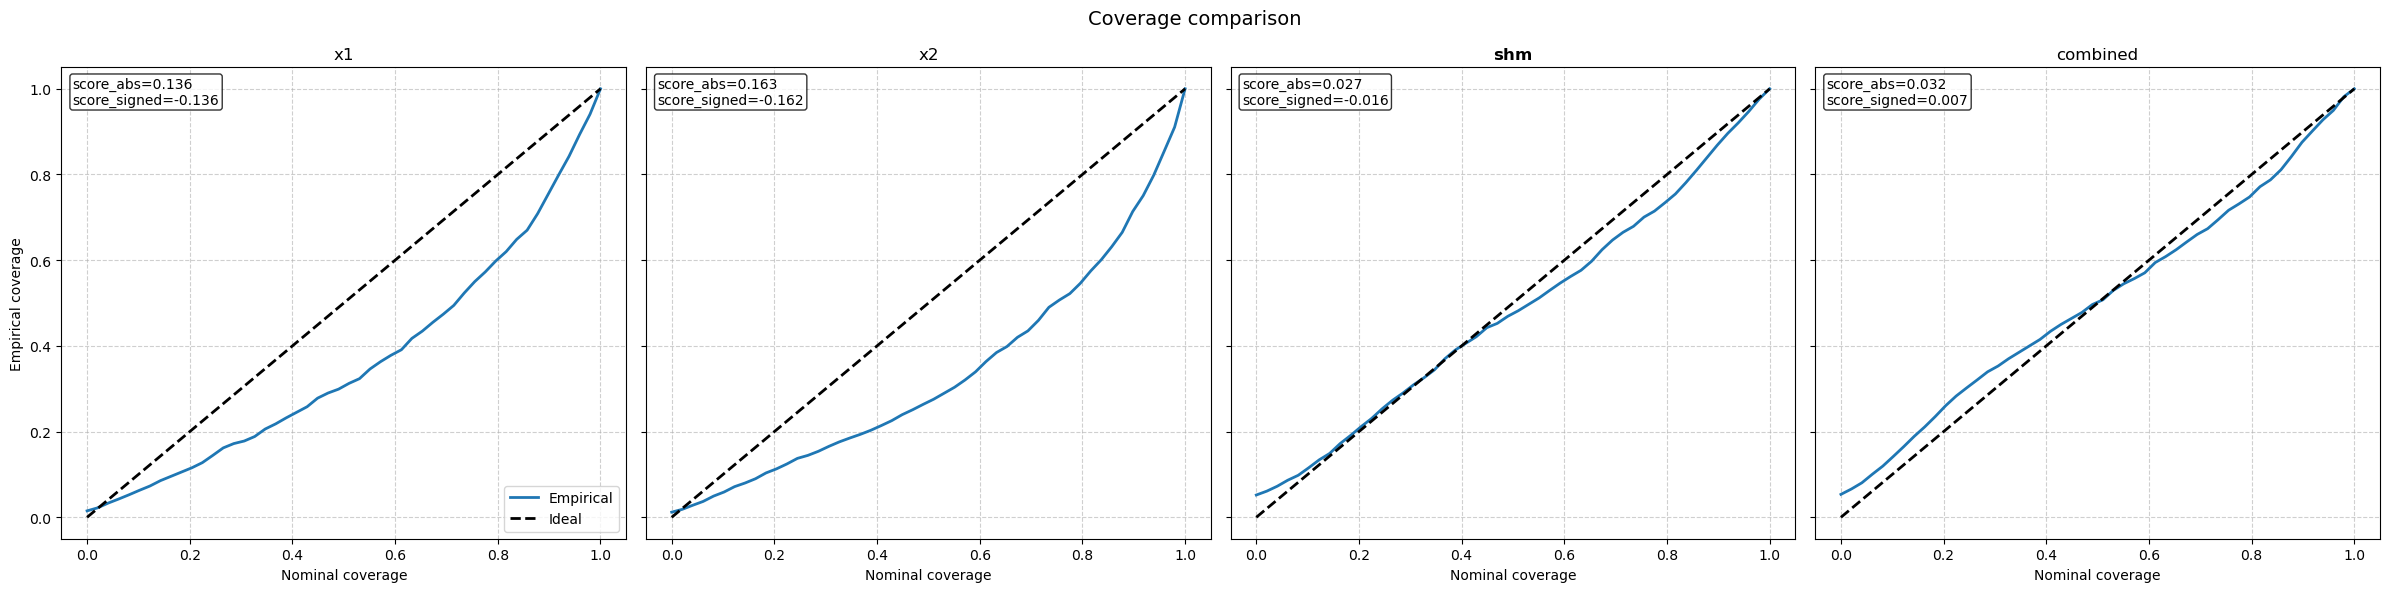

In [7]:
# ==========================================================
# Coverage comparisons in a smaller parameter space
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=2000,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.7)
)

## 3. Accuracy & Precision Metrics

Complement coverage tests with direct measurements of posterior accuracy and sharpness. The evaluation excludes zero-event spectra to avoid misleading distances in exclusion regions.

### 3.1 Full Parameter Space (no window)

Metrics computed across the full parameter space (no windowing).

Loading dataset from:
data/datasets/wimpy/shm/wimpy_n300000_low_shm.pt

Non-zero test samples: 20750


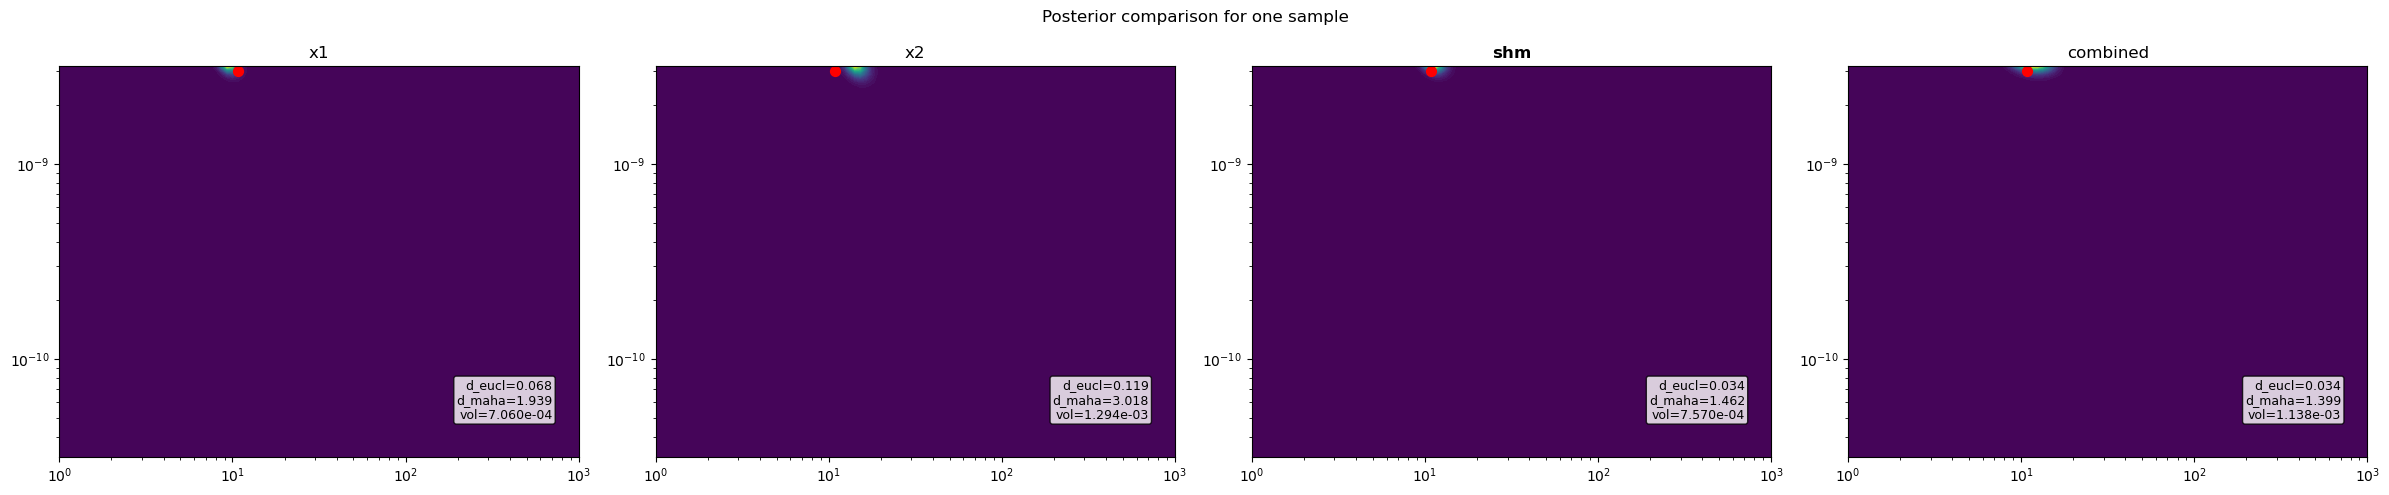

In [8]:
performances = evaluate_posterior_quality_halo(
    models,
    labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    device=device,
    posteriorbins=100,
    n_samples=2000,
    plotting=True,
    plotting_index=40,
)

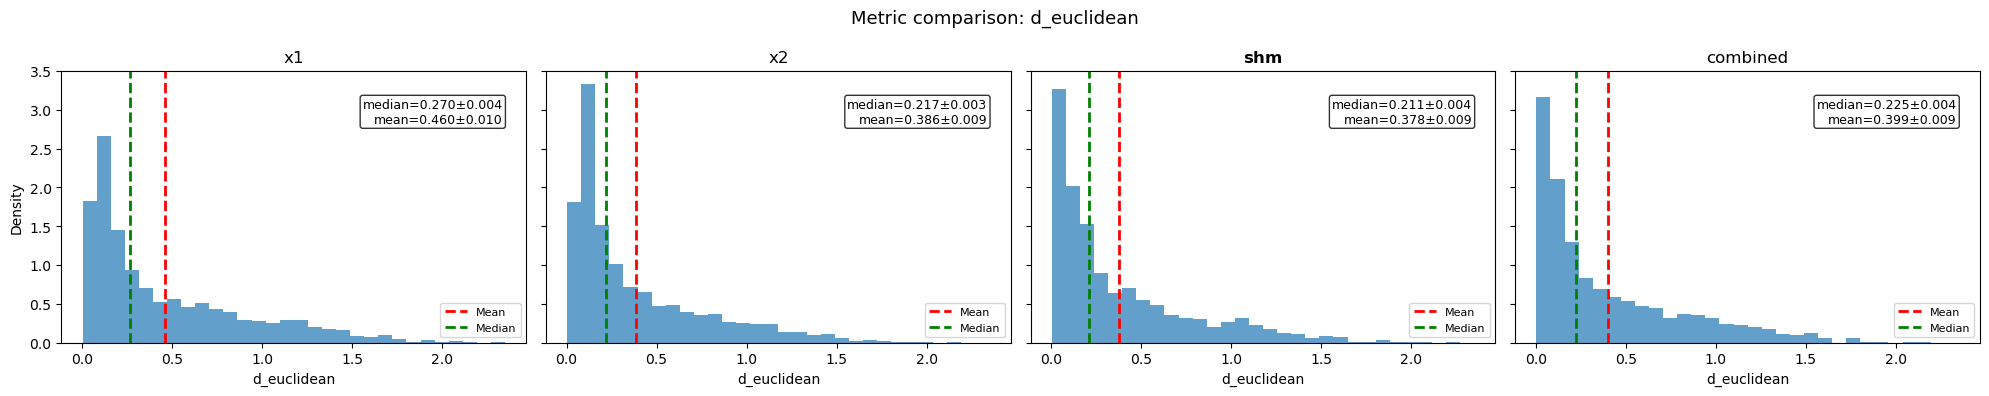

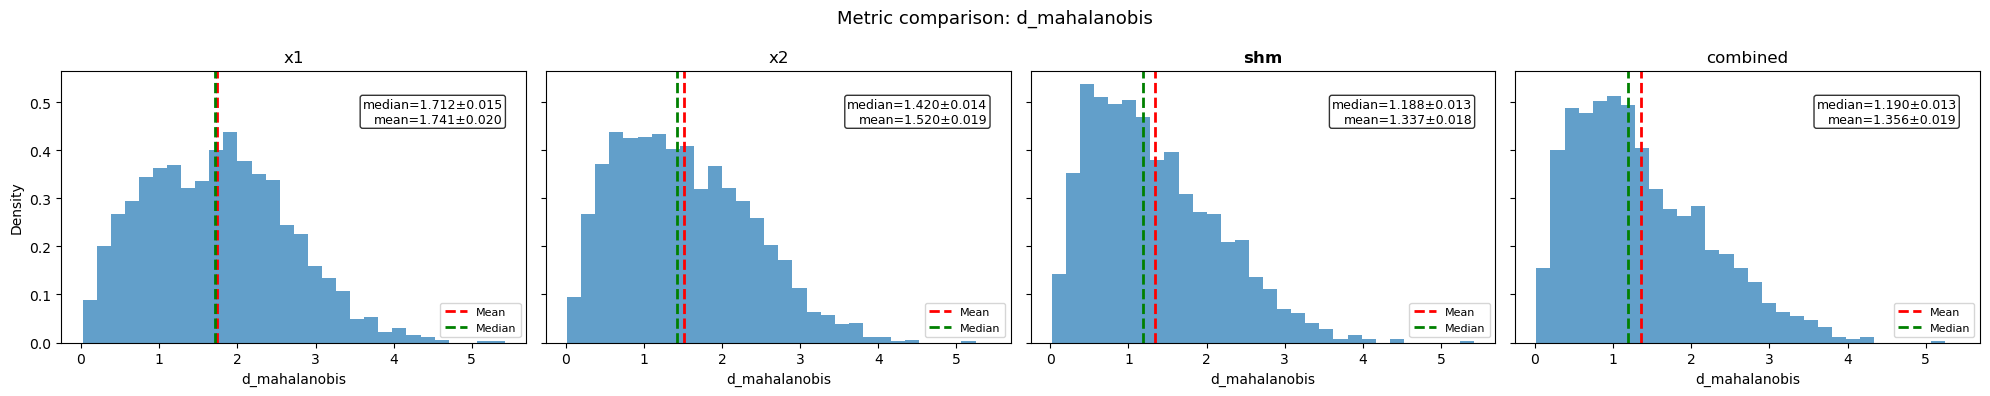

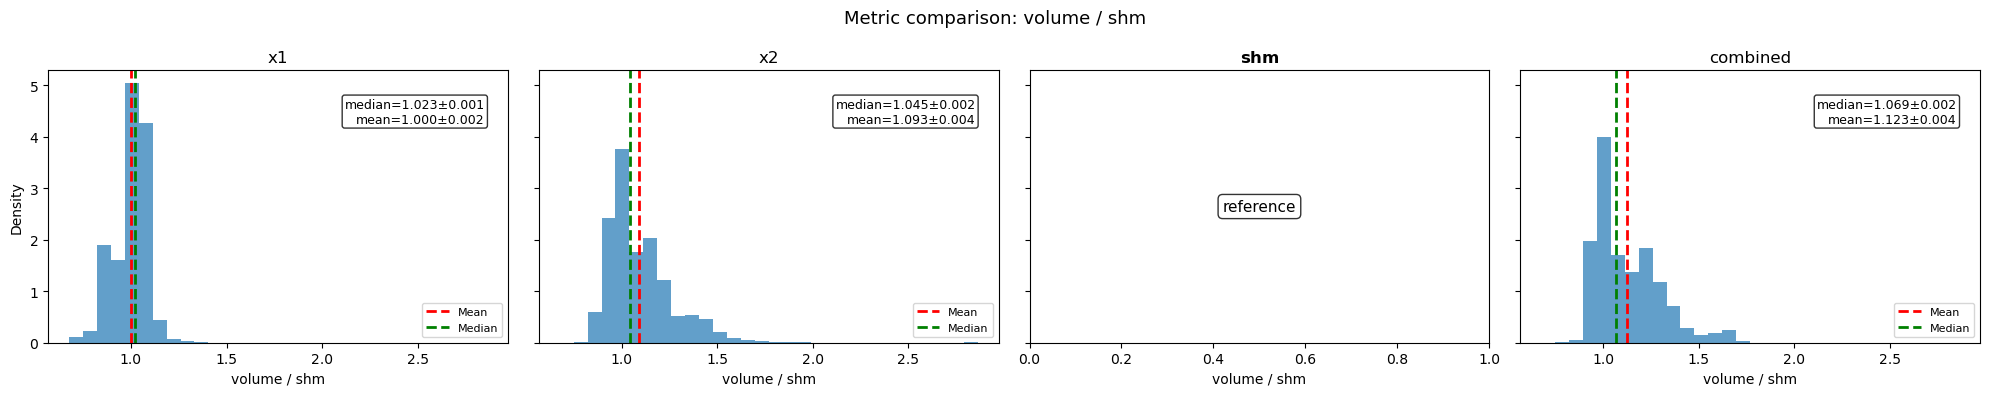

In [9]:
for metric in ["d_euclidean", "d_mahalanobis", "volume"]:
    compare_metric_histograms(
        performances,
        metric=metric,
        bins=30,
        reference_label=halo_choice,
    )

### 3.2 Focused Parameter Window

Same metrics restricted to a focused parameter window to highlight halo-dependent differences.

In [10]:
performances_windowed = evaluate_posterior_quality_halo(
    models,
    labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    device=device,
    posteriorbins=100,
    n_samples=2000,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.5),
)

Loading dataset from:
data/datasets/wimpy/shm/wimpy_n300000_low_shm.pt

Filtered test samples: 8818
Non-zero test samples: 6768
Evaluating model: x1
Evaluating model: x2
Evaluating model: shm
Evaluating model: combined


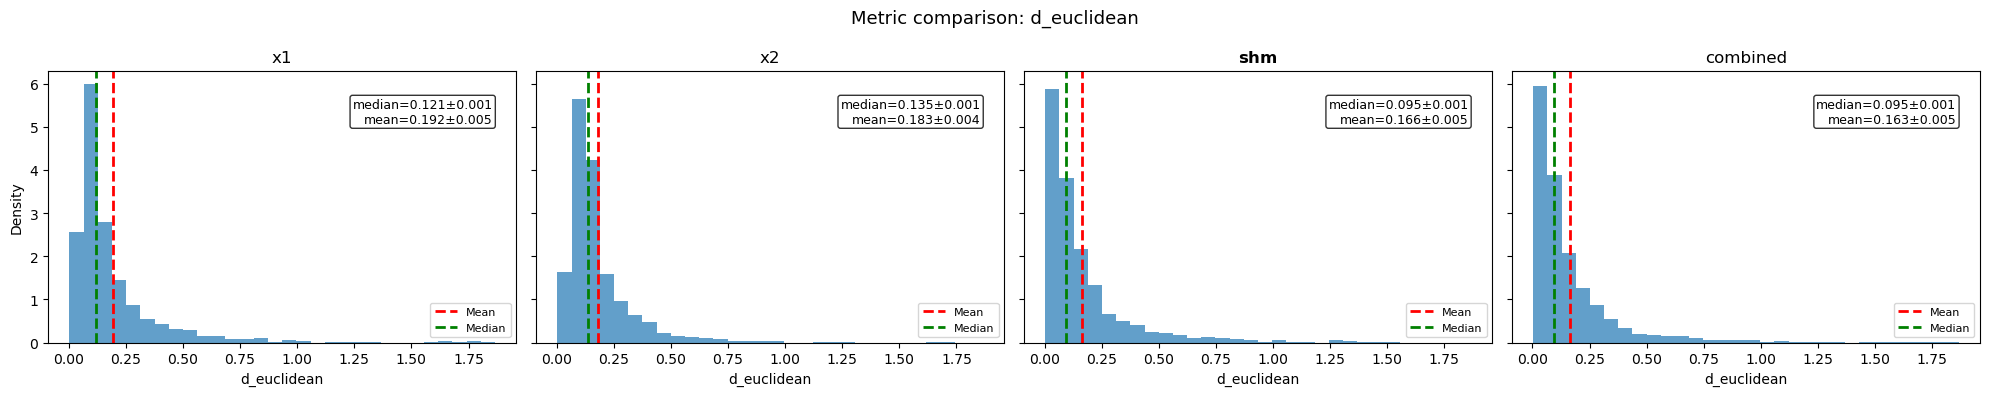

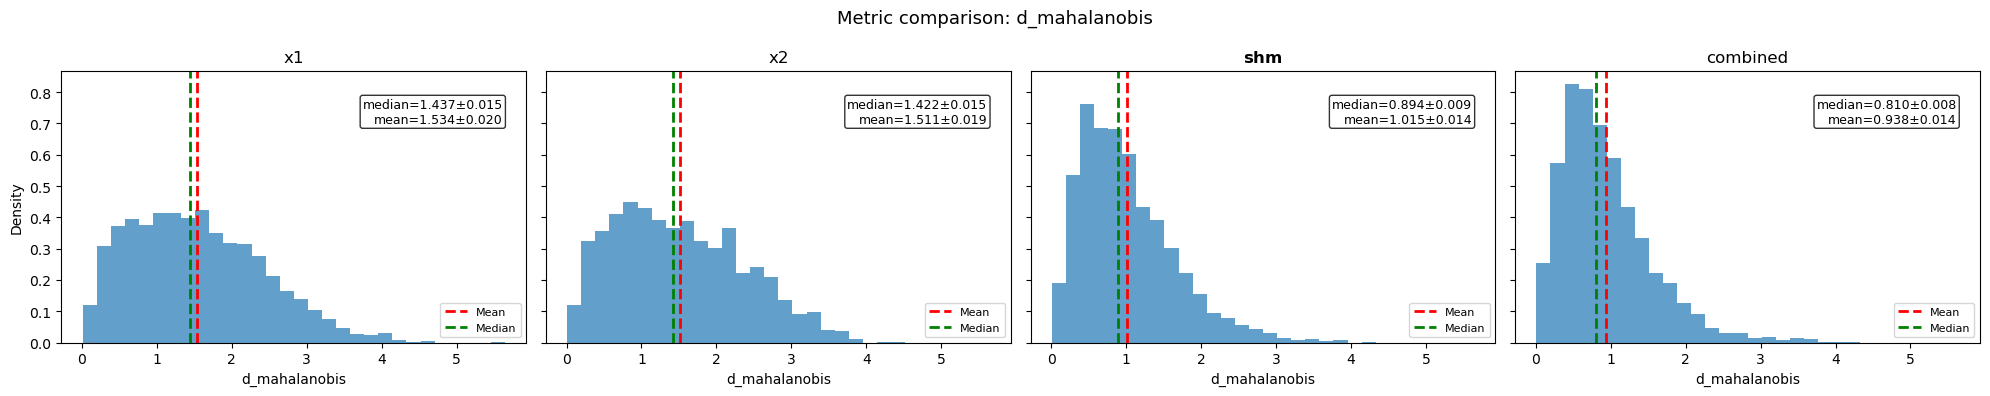

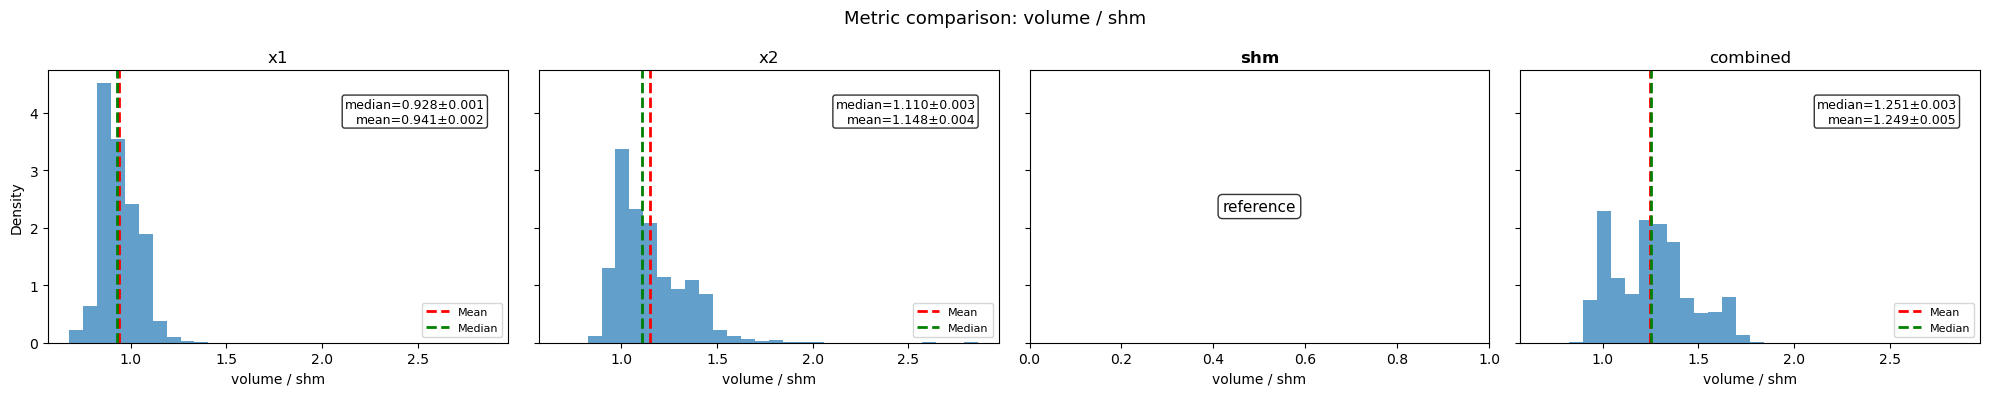

In [11]:
for metric in ["d_euclidean", "d_mahalanobis", "volume"]:
    compare_metric_histograms(
        performances_windowed,
        metric=metric,
        bins=30,
        reference_label=halo_choice,
    )

## Summary

Comparing x1, x2, and SHM halo models:
- **SHM** is the best-calibrated when it is the true halo
- **Extreme models** show clear degradation under misspecification
- **Combined posterior** provides a robust fallback across halo assumptions
- **Volume and distance metrics** clarify how SHM relates to extreme cases

**Key Findings in the Focused Window**:
- **SHM (true halo)**: Best coverage and smallest distances
- **x1/x2**: Undercoverage and larger distances when misspecified
- **Combined**: More conservative but robust across models